# Phase 2 - Exploratory Data Analysis

## Healthcare AI System

**Input**: `outputs/model_table.csv` — 25,000 rows, 20 columns\
**Output**: `Engineered model_table.csv` ready for Phase 3 Modeling

## EDA Philosophy: What Architects Look For
A data scientist asks: "What does the data look like?"\
An architect asks: "What will this data do to my model?"

These are four questions every architect answers before touching a model:

**1. Are the labels meaningful?**\
If labels are random, no model can learn them. Period.

**2. Is there class imbalance?**\
Imbalance causes models to ignore minority classes entirely — called class collapse.

**3. Which features have real signal?**\
Correlation tells us where to focus feature engineering effort.

**4. Are outliers errors or reality?**\
In healthcare, extreme values are often the most important rows.

The answers to these four questions shape every modeling decision we make in Phase 3.

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [2]:
# Load Model Tables
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [3]:
# Convert date columns
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] = pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

## Distribution Analysis
### Step 1 - Missing Values Analysis
First thing we always check — what is missing and why.\
Not all nulls are data errors. Some are business logic.

In [4]:
# Overall null check
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
claim_status               0
billed_amount              0
bill_id                    0
doctor_id                  0
risk_score                 0
length_of_stay_hours       0
visit_type                 0
department                 0
visit_date                 0
visit_id                   0
registration_date          0
chronic_flag               0
insurance_provider         0
city                       0
gender                     0
billing_date               0
dtype: int64

In [5]:
# Focus on key columns 
df[["approved_amount", "payment_days","length_of_stay_hours"]].isnull().sum()

approved_amount         1318
payment_days             790
length_of_stay_hours       0
dtype: int64

### Step 2 — Business Logic Validation
Three checks before we touch any model.\
We are validating that the data makes **business sense** — not just statistical sense.

In [6]:
# Check A - paid claims should always have an approved amount
# if this returns 0, then we are clean

df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
].shape

(817, 20)

In [7]:
 # Check B - payment days missing breakdown by claim status
df[(df["payment_days"].isna())]["claim_status"].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

In [8]:
# Check C - LOS should never be negative
(df["length_of_stay_hours"]<0).sum()

np.int64(0)

### Step 3 — Distribution Analysis
We look at every important column — categorical and numeric.\
Goal: understand the shape of our data before building any model.

In [9]:
# Categorical column reports
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

======Visit Type=================
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

=======City=======================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


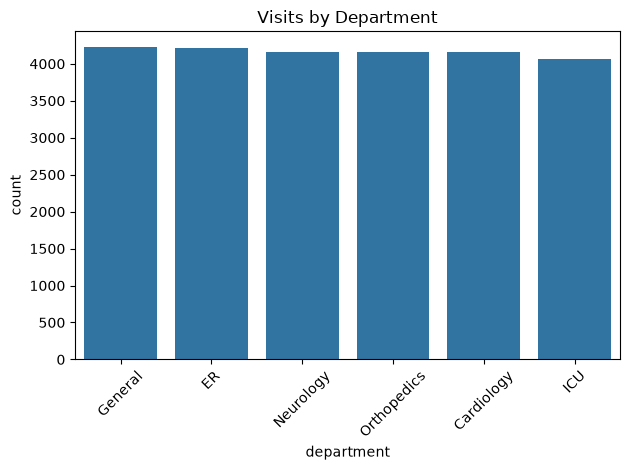

In [10]:
# Bar chart showing vsits by department
sns.countplot(data=df, x="department", order=df['department'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

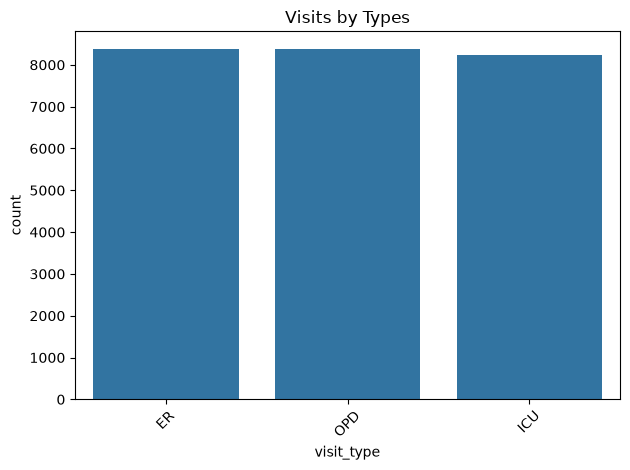

In [11]:
# Bar chart showing vsits by types
sns.countplot(data=df, x="visit_type", order=df['visit_type'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Types")
plt.tight_layout()
plt.show()

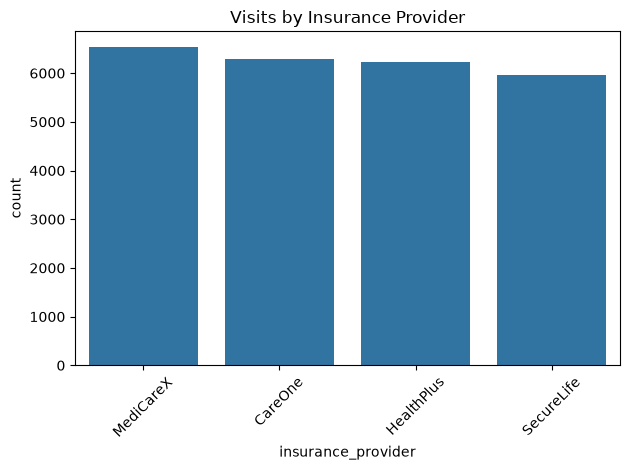

In [12]:
# Bar chart showing vsits by Insurance Providers
sns.countplot(data=df, x="insurance_provider", order=df['insurance_provider'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Insurance Provider")
plt.tight_layout()
plt.show()

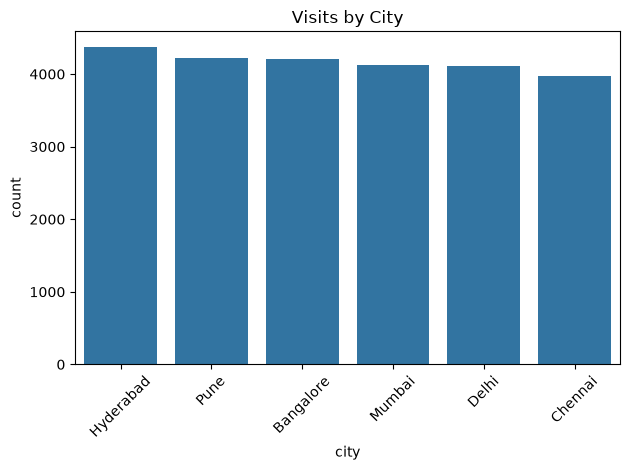

In [13]:
# Bar chart showing vsits by City
sns.countplot(data=df, x="city", order=df['city'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by City")
plt.tight_layout()
plt.show()

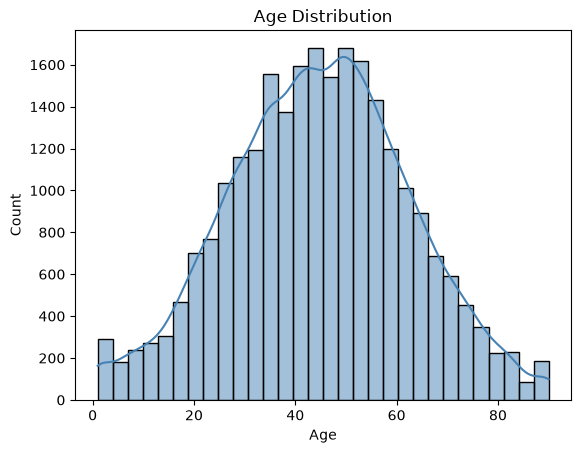

count    25000.00
mean        44.77
std         17.78
min          1.00
25%         33.00
50%         45.00
75%         57.00
max         90.00
Name: age, dtype: float64


In [14]:
# Age Distribution
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe().round(2))

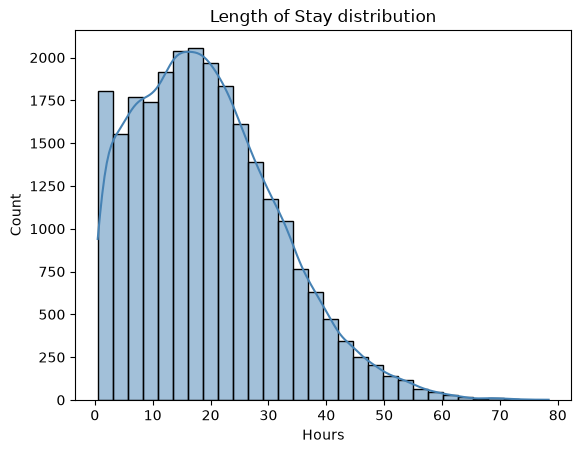

count    25000.00
mean        19.55
std         12.31
min          0.50
25%          9.96
50%         18.20
75%         27.31
max         78.42
Name: length_of_stay_hours, dtype: float64


In [15]:
# Length of Stay Distribution
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay distribution")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [16]:
"""
IQR = Interquartile Range - the spread of the middle 50% of your data
25% = 9.96  (bottom quarter boundary)
75% = 27.31 (top quarter boundary)
"""
IQR = 27.31 - 9.96
print(IQR)

17.349999999999998


In [17]:
# Upper Fence
"""
An upper fence is the cutoff, beyond which a value is considered to an outlier
upper_fence = 75% + (1.5*IQR)
John's variable = 1.5 (universal multiplier)
"""
upper_fence = 27.31 + (1.5 * IQR)
print(upper_fence)

53.334999999999994


## Outlier Detection
### Step 4 — Outlier Detection
Two approaches:

* **Boxplot** — visual detection
* **IQR method** — numerical calculation
**IQR = Q3 − Q1** (middle 50% of data)

Lower bound = Q1 − 1.5 × IQR\
Upper bound = Q3 + 1.5 × IQR

Anything outside these bounds = outlier.

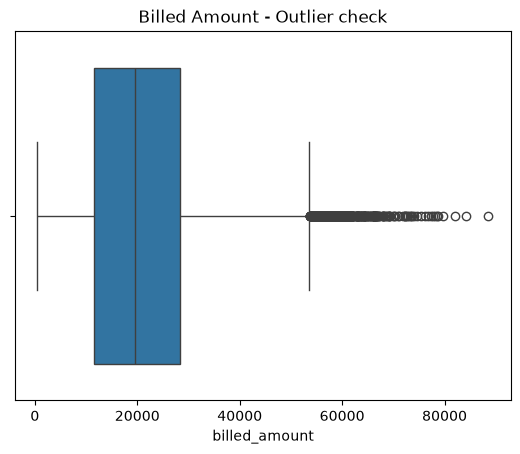

In [ ]:
# Billed Amount  Outlier Check
sns.boxplot(x=df["billed_amount"])
plt.title("Billed Amount - Outlier Check")
plt.show()

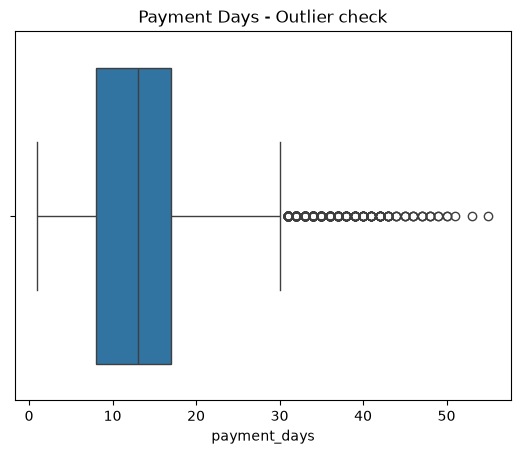

In [ ]:
# Payment Days outlier check
sns.boxplot(x=df['payment_days'])
plt.title("Payment Days - Outlier Check")
plt.show()

Text(0.5, 1.0, 'Length of Stays - Outlier Check')

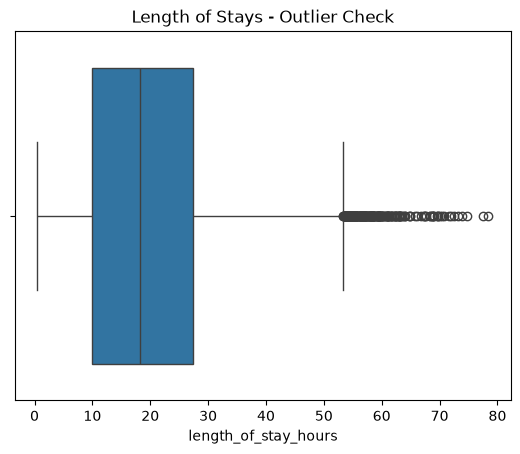

In [20]:
# LEngth of Stays outlier check
sns.boxplot(x=df["length_of_stay_hours"])
plt.title("Length of Stays - Outlier Check")

In [21]:
# IQR explicit calculation — numbers behind the boxplot
for col in ["length_of_stay_hours", "payment_days", "billed_amount"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"{col}")
    print(f"  Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
    print(f"  Lower bound = {lower:.1f}  |  Upper bound = {upper:.1f}")
    print(f"  Outliers    = {n_out} rows")
    print()

length_of_stay_hours
  Q1 = 10.0  |  Q3 = 27.3  |  IQR = 17.4
  Lower bound = -16.1  |  Upper bound = 53.3
  Outliers    = 256 rows

payment_days
  Q1 = 8.0  |  Q3 = 17.0  |  IQR = 9.0
  Lower bound = -5.5  |  Upper bound = 30.5
  Outliers    = 509 rows

billed_amount
  Q1 = 11582.5  |  Q3 = 28398.1  |  IQR = 16815.6
  Lower bound = -13641.0  |  Upper bound = 53621.5
  Outliers    = 373 rows

